# ML Fundamentals

Core machine learning (ML), built by hand. Pattern for every section: **build it in NumPy → see it in a plot → mirror it in PyTorch**. Runs locally (Apple's Metal Performance Shaders — MPS) or on Google Colab (GPU) unchanged.

| # | Section | Status |
|---|---------|--------|
| 1 | Linear regression
| 2 | Loss functions
| 3 | Logistic regression
| 4 | Backpropagation → first neural net
| 5 | Neural networks, deeper
| 6 | Overfitting / underfitting
| 7 | Bootstrapping & bagging
| 8 | Recurrent neural networks (RNNs)

Run top to bottom; doing the 🦾 exercises as you go. Each section ends with some learning resources if you want to go deeper.

In [152]:
# numpy, matplotlib, torch are preinstalled on Colab — nothing to pip install.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available()          # Colab GPU
    else "mps" if torch.backends.mps.is_available()  # Mac M-series
    else "cpu"
)
print(f"torch {torch.__version__} on {device}")

rng = np.random.default_rng(42)
torch.manual_seed(42)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

torch 2.12.1 on mps


---
## 1. Linear Regression

**Why start here:** fitting a line is the simplest possible "learning," yet it already contains the complete recipe that every model in this notebook — including neural nets — reuses:

1. **Model**: a function with tunable knobs. Here: $\hat{y} = wx + b$
2. **Loss**: one number scoring how wrong we are. Here, **mean squared error (MSE)** — the average squared miss, $\frac{1}{N}\sum (\hat{y}_i - y_i)^2$. Squaring makes big misses hurt disproportionately, and keeps the math smooth.
3. **Optimize**: **gradient descent** — compute the slope of the loss with respect to each knob, step downhill, repeat: $w \leftarrow w - \eta \, \partial L/\partial w$

With residual $r_i = \hat{y}_i - y_i$, the chain rule gives:

$$\frac{\partial L}{\partial w} = \frac{2}{N}\sum r_i x_i \qquad \frac{\partial L}{\partial b} = \frac{2}{N}\sum r_i$$

Each point pulls proportionally to how wrong it is ($r_i$) × its leverage ($x_i$).

📚 *Deeper dive: [Google ML Crash Course — Linear regression](https://developers.google.com/machine-learning/crash-course/linear-regression) (interactive, includes a full gradient-descent unit)*

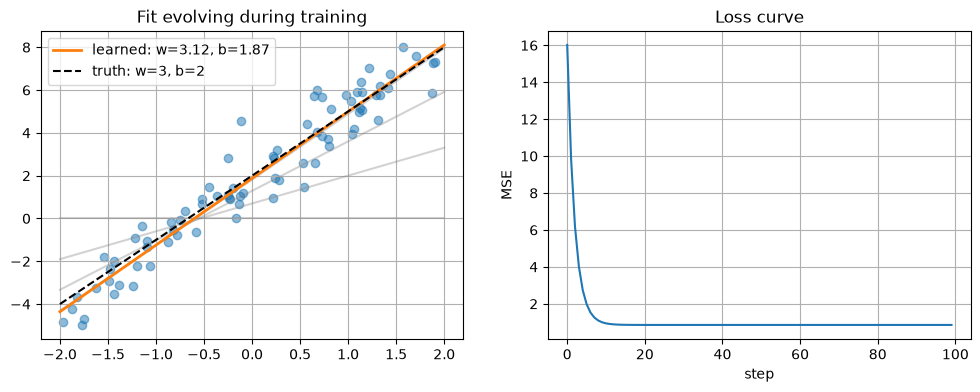

In [153]:
# Data from a known truth (y = 3x + 2 + noise) so we can check learning worked.
TRUE_W, TRUE_B, N = 3.0, 2.0, 80
x = rng.uniform(-2, 2, size=N)
y = TRUE_W * x + TRUE_B + rng.normal(0, 1.0, size=N)

# Gradient descent, by hand
w, b, lr = 0.0, 0.0, 0.1
history = []
for step in range(100):
    r = (w * x + b) - y                      # residuals
    history.append((w, b, np.mean(r**2)))
    w -= lr * 2 * np.mean(r * x)
    b -= lr * 2 * np.mean(r)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(x, y, alpha=0.5)
xs = np.array([-2, 2])
for s in [0, 2, 5, 15]:                      # snapshots of the fit improving
    ax1.plot(xs, history[s][0] * xs + history[s][1], color="gray", alpha=0.35)
ax1.plot(xs, w * xs + b, "C1", lw=2, label=f"learned: w={w:.2f}, b={b:.2f}")
ax1.plot(xs, TRUE_W * xs + TRUE_B, "k--", label="truth: w=3, b=2")
ax1.legend(); ax1.set_title("Fit evolving during training")
ax2.plot([h[2] for h in history])
ax2.set_xlabel("step"); ax2.set_ylabel("MSE"); ax2.set_title("Loss curve")
plt.show()

**🎬 Watch the walk.** The plots above are snapshots; this animation plays the whole thing. The key mental model: the fit line wiggling in **data space** (left) and a single point rolling downhill in **parameter space** (right) are *the same event* — every gradient step moves the point one notch down the loss bowl, which is the line fitting one notch better. Hold onto that picture: training any model, from this line to a billion-parameter network, is always a ball rolling down a (much lumpier) bowl.

In [154]:
from IPython.display import Video

# Rendered with Manim (source: manim/gradient_descent_viz.py — same data, same lr).
# On Colab: run from the cloned repo so the assets/ folder is present.
Video("assets/gradient-descent-two-views.mp4", width=880)

**Same thing in PyTorch.** Autograd computes our hand-derived gradients automatically: `loss.backward()` fills `.grad` with exactly the $\frac{2}{N}\sum r_i x_i$ we wrote above. The optimizer is `SGD` — **stochastic gradient descent** — plain gradient descent, named for the random mini-batches it's usually fed (here we use the full batch). This forward → backward → step loop is the skeleton of every PyTorch model you'll ever train.

In [155]:
xt = torch.tensor(x, dtype=torch.float32, device=device)   # float32: MPS has no float64
yt = torch.tensor(y, dtype=torch.float32, device=device)

wt = torch.zeros(1, device=device, requires_grad=True)
bt = torch.zeros(1, device=device, requires_grad=True)
opt = torch.optim.SGD([wt, bt], lr=0.1)

for step in range(100):
    loss = torch.mean((wt * xt + bt - yt) ** 2)   # forward
    opt.zero_grad()
    loss.backward()                               # autograd = our chain rule
    opt.step()                                    # w -= lr * w.grad

print(f"numpy by hand : w={w:.4f}, b={b:.4f}")
print(f"torch autograd: w={wt.item():.4f}, b={bt.item():.4f}   ← identical")

numpy by hand : w=3.1164, b=1.8737
torch autograd: w=3.1164, b=1.8737   ← identical


### 🧪 Try it
1. **Learning-rate safari:** rerun with `lr` = 0.01, 0.5, 1.1 and plot the three loss curves. One is slow, one is good, one explodes — explain why.
2. **Vectorize:** 3 features, `y = X @ [1.5, -2, 0.5] + 4 + noise`. Gradient becomes `dw = 2/N * X.T @ r`. Recover all three weights.
3. **Closed form:** linear regression has an exact solution, `np.linalg.solve(X.T @ X, X.T @ y)` (normal equation). Verify it matches — then remember that *nothing nonlinear has one*, which is why gradient descent runs the world.

In [156]:
# 🧪 scratch — Section 1


---
## 2. Loss Functions

**Why care:** the loss *defines what "good" means* — same data + same model + different loss = different answer. Choosing a loss is choosing which mistakes you can live with. Three regression losses, as functions of the residual $r$:

| Loss | Shape | Personality | Minimizer targets |
|------|-------|-------------|-------------------|
| **Mean squared error (MSE)** | $r^2$ | punishes big errors quadratically → outlier-obsessed | mean |
| **Mean absolute error (MAE)** | $\lvert r \rvert$ | all errors count equally → robust | median |
| **Huber** | quadratic→linear at $\delta$ | best of both | in between |

📚 *Deeper dive: [Cornell CS4780 — Empirical Risk Minimization](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote10.html) (squared vs absolute vs Huber, side by side)*

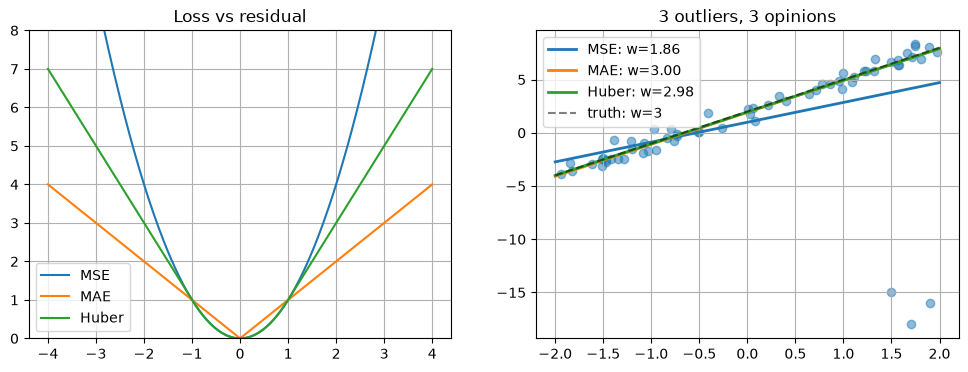

In [157]:
# Left: loss shapes. Right: fit lines when 3 outliers poison the data.
x2 = rng.uniform(-2, 2, size=60)
y2 = 3 * x2 + 2 + rng.normal(0, 0.5, size=60)
x2 = np.append(x2, [1.5, 1.7, 1.9]); y2 = np.append(y2, [-15, -18, -16])  # sensor glitches

def fit_line(grad_of_r, lr=0.05, steps=500):
    """Only dL/dr differs between losses — the chain rule does the rest."""
    w, b = 0.0, 0.0
    for _ in range(steps):
        g = grad_of_r(w * x2 + b - y2)
        w -= lr * np.mean(g * x2); b -= lr * np.mean(g)
    return w, b

fits = {
    "MSE":   fit_line(lambda r: 2 * r),
    "MAE":   fit_line(lambda r: np.sign(r)),
    "Huber": fit_line(lambda r: np.where(np.abs(r) <= 1, 2 * r, 2 * np.sign(r))),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
r = np.linspace(-4, 4, 400)
ax1.plot(r, r**2, label="MSE"); ax1.plot(r, np.abs(r), label="MAE")
ax1.plot(r, np.where(np.abs(r) <= 1, r**2, 2 * np.abs(r) - 1), label="Huber")
ax1.set_ylim(0, 8); ax1.legend(); ax1.set_title("Loss vs residual")
ax2.scatter(x2, y2, alpha=0.5)
xs = np.array([-2, 2])
for name, (wf, bf) in fits.items():
    ax2.plot(xs, wf * xs + bf, lw=2, label=f"{name}: w={wf:.2f}")
ax2.plot(xs, 3 * xs + 2, "k--", alpha=0.5, label="truth: w=3")
ax2.legend(); ax2.set_title("3 outliers, 3 opinions")
plt.show()

**For classification: cross-entropy.** When the model outputs a probability, squared error is the wrong ruler — we need a loss that measures *how surprised the model is by the true label*. That's **binary cross-entropy (BCE)**: $-[y \log p + (1-y)\log(1-p)]$. Two reasons it wins: being *confidently wrong* costs $\to \infty$ (MSE caps that mistake at 1), and its gradient through a sigmoid collapses to the clean $p - y$ — no vanishing plateau. Section 3 uses it.

PyTorch ships all of these: `nn.MSELoss`, `nn.L1Loss` (MAE), `nn.HuberLoss`, `nn.BCEWithLogitsLoss`.

📚 *Deeper dive: [Chris Olah — Visual Information Theory](https://colah.github.io/posts/2015-09-Visual-Information/) (where cross-entropy actually comes from)*

### 🧪 Try it
1. **Mean vs median:** for `data = np.append(rng.normal(5, 1, 50), [50.0])`, plot total MSE and MAE of a constant prediction $c$ over `linspace(0, 15)`. Confirm the minima land on `data.mean()` vs `np.median(data)`.
2. **Confidently wrong:** plot BCE and $(p-1)^2$ vs $p$ for true label $y=1$. Compare slopes near $p = 0.01$ — which loss is still screaming?
3. **Sanity vs torch:** check `nn.HuberLoss(delta=1.0)` agrees with our `huber` on random residuals.

In [158]:
# 🧪 scratch — Section 2


---
## 3. Logistic Regression

**Why:** we want class predictions, but a hard "0 or 1" output has no slope to descend — so we predict a *probability* instead and keep the whole Section 1 recipe. Two swaps: squash the linear output with a **sigmoid** (an S-shaped curve mapping any real number into $(0,1)$): $p = \sigma(\mathbf{w}^\top\mathbf{x} + b)$, and score with the binary cross-entropy from Section 2. Differentiate BCE through the sigmoid and everything cancels to

$$\frac{\partial L}{\partial z} = p - y \qquad\Rightarrow\qquad \frac{\partial L}{\partial \mathbf{w}} = \tfrac{1}{N} X^\top(p - y)$$

— *residual × input*, the same form as linear regression. This "linear core + nonlinearity + matched loss" unit is the atom neural nets are built from.

📚 *Deeper dive: [Google ML Crash Course — Logistic regression](https://developers.google.com/machine-learning/crash-course/logistic-regression); for the full derivation, [Stanford CS229 notes, ch. 2](https://cs229.stanford.edu/main_notes.pdf)*

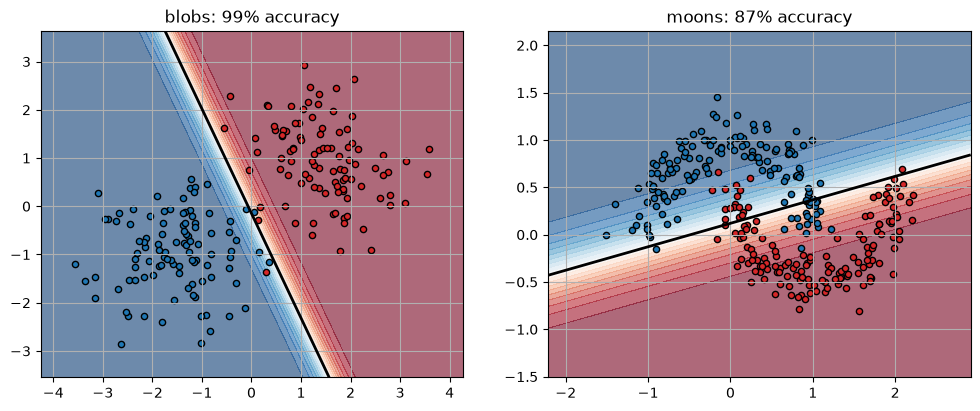

In [159]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce_loss(p, y, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def train_logreg(X, y, lr=0.5, steps=2000):
    w, b = np.zeros(X.shape[1]), 0.0
    for _ in range(steps):
        err = sigmoid(X @ w + b) - y          # the magic dL/dz = p - y
        w -= lr * (X.T @ err) / len(y)
        b -= lr * np.mean(err)
    return w, b

def plot_boundary(ax, predict_proba, X, y, title):
    pad = 0.7
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 200),
                         np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 200))
    pp = predict_proba(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, pp, levels=20, cmap="RdBu_r", alpha=0.6, vmin=0, vmax=1)
    ax.contour(xx, yy, pp, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(*X[y == 0].T, c="C0", edgecolor="k", s=20)
    ax.scatter(*X[y == 1].T, c="C3", edgecolor="k", s=20)
    ax.set_title(title)

def make_moons(n=300, noise=0.15):
    """Two interleaving half-circles — hand-rolled, no sklearn."""
    t = np.linspace(0, np.pi, n // 2)
    X = np.vstack([np.column_stack([np.cos(t), np.sin(t)]),
                   np.column_stack([1 - np.cos(t), 0.5 - np.sin(t)])])
    X += rng.normal(0, noise, size=X.shape)
    return X, np.repeat([0.0, 1.0], n // 2)

# Easy: two blobs. Hard: two moons.
X_blobs = np.vstack([rng.normal([-1.5, -1], 0.8, (100, 2)), rng.normal([1.5, 1], 0.8, (100, 2))])
y_blobs = np.repeat([0.0, 1.0], 100)
X_moons, y_moons = make_moons()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, Xd, yd, name in [(ax1, X_blobs, y_blobs, "blobs"), (ax2, X_moons, y_moons, "moons")]:
    wl, bl = train_logreg(Xd, yd)
    acc = np.mean((sigmoid(Xd @ wl + bl) > 0.5) == yd)
    plot_boundary(ax, lambda G: sigmoid(G @ wl + bl), Xd, yd, f"{name}: {acc:.0%} accuracy")
plt.show()

**The built-in ceiling:** the boundary is where $\mathbf{w}^\top\mathbf{x} + b = 0$ — a straight line, *no matter how long you train*. Blobs: solved. Moons: stuck, because no line separates them. That failure is exactly what hidden layers fix in Section 4.

### 🧪 Try it
1. **Derive the magic:** on paper, show BCE + sigmoid ⟹ $\partial L/\partial z = p - y$ (you need $\sigma' = \sigma(1-\sigma)$).
2. **Uncertainty:** regenerate blobs with `scale=2.0` so they overlap. The probability map develops a wide soft band — the model *knows* where it's unsure.
3. **Beat the moons without a neural net:** augment features to `[x1, x2, x1², x2², x1·x2]` and retrain. Linear in 5-D = curved in 2-D. (This is the kernel idea — hidden layers automate it.)
4. **Torch one-liner:** same model is `nn.Linear(2, 1)` + `nn.BCEWithLogitsLoss()` (note: it takes raw logits, no sigmoid). Match your NumPy accuracy.

In [160]:
# 🧪 scratch — Section 3


---
## 4. Backpropagation → First Neural Net

**Why:** we hand-derived gradients twice already — that doesn't scale to models with millions of parameters. **Backpropagation** ("backprop") is the fix: the chain rule run *backward* through the model, reusing intermediate results so all gradients together cost about one extra forward pass. It's the algorithm that trains every neural network. Our net (one hidden layer, to crack the moons):

$$X \xrightarrow{W_1, b_1} Z_1 \xrightarrow{\tanh} A_1 \xrightarrow{W_2, b_2} z_2 \xrightarrow{\sigma} p \xrightarrow{\text{BCE}} L$$

Backward, right to left ($\delta$ = error signal flowing back):

| step | gradient | pattern |
|------|----------|---------|
| output | $\delta_2 = (p - y)/N$ | Section 3's magic |
| $W_2$ | $A_1^\top \delta_2$ | inputᵀ × error |
| hidden | $\delta_1 = (\delta_2 W_2^\top) \odot (1 - A_1^2)$ | route back, gate by $\tanh'$ |
| $W_1$ | $X^\top \delta_1$ | inputᵀ × error, again |

Every layer: **(input to layer)ᵀ × (error at layer)**. A 100-layer net is this table repeated.

📚 *Deeper dive: [Stanford CS231n — Backpropagation, Intuitions](https://cs231n.github.io/optimization-2/); prefer visuals first? [3Blue1Brown — Backpropagation calculus](https://www.3blue1brown.com/lessons/backpropagation-calculus)*

**🎬 The table, in motion.** Blue pulses are the forward pass computing (and remembering) each layer; the red wave is the error signal δ retracing the same edges backward, dropping off a gold gradient at every layer it crosses. Watch for the repeated move — inputᵀ × error at W₂, then again at W₁ — that's the whole algorithm.

In [161]:
from IPython.display import Video

# Rendered with Manim (source: manim/backprop_viz.py).
Video("assets/backprop-flow.mp4", width=880)

In [162]:
def init_mlp(n_in, n_hidden, seed=0):
    r = np.random.default_rng(seed)
    return {"W1": r.normal(0, 0.5, (n_in, n_hidden)), "b1": np.zeros(n_hidden),
            "W2": r.normal(0, 0.5, (n_hidden, 1)),    "b2": np.zeros(1)}

def forward(params, X):
    A1 = np.tanh(X @ params["W1"] + params["b1"])
    p = sigmoid(A1 @ params["W2"] + params["b2"]).ravel()
    return p, A1                                     # keep A1 — backprop needs it

def backward(params, X, A1, p, y):
    d2 = ((p - y) / len(y))[:, None]                 # dL/dz2 = (p-y)/N
    d1 = (d2 @ params["W2"].T) * (1 - A1**2)         # route back, gate by tanh'
    return {"W1": X.T @ d1, "b1": d1.sum(0), "W2": A1.T @ d2, "b2": d2.sum(0)}

**Trust, but verify.** Backprop bugs are silent — the net still trains, just badly. Referee: build the *same* network in PyTorch, run `loss.backward()`, and compare autograd's gradients to ours, element by element.

In [163]:
params = init_mlp(2, 16)
Xs, ys = X_moons[:32], y_moons[:32]

# Our gradients
p, A1 = forward(params, Xs)
ours = backward(params, Xs, A1, p, ys)

# Autograd's gradients on identical weights (CPU + float64 for exact comparison)
tp = {k: torch.tensor(v, requires_grad=True) for k, v in params.items()}
Xt, yt2 = torch.tensor(Xs), torch.tensor(ys)
z2 = torch.tanh(Xt @ tp["W1"] + tp["b1"]) @ tp["W2"] + tp["b2"]
nn.functional.binary_cross_entropy_with_logits(z2.ravel(), yt2).backward()

for k in params:
    err = np.abs(ours[k] - tp[k].grad.numpy()).max()
    print(f"{'✅' if err < 1e-9 else '❌'} {k}: max |ours − autograd| = {err:.2e}")

✅ W1: max |ours − autograd| = 2.78e-17
✅ b1: max |ours − autograd| = 5.55e-17
✅ W2: max |ours − autograd| = 2.78e-17
✅ b2: max |ours − autograd| = 0.00e+00


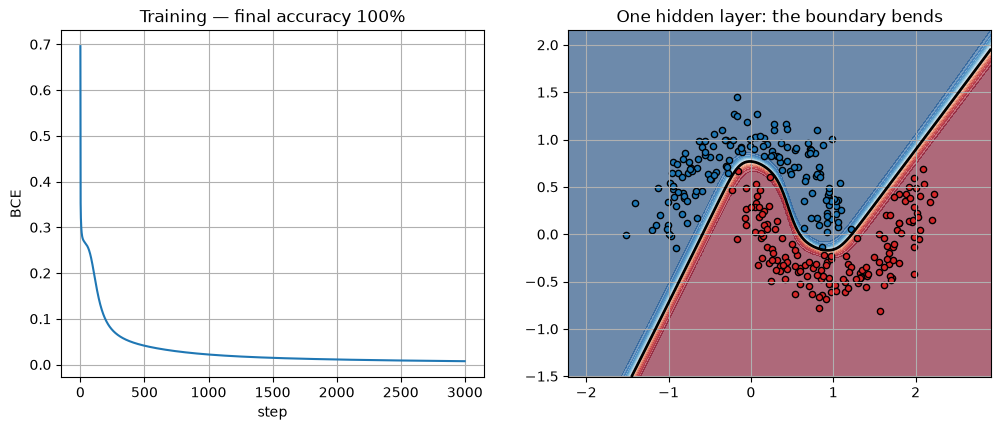

In [164]:
# The payoff: our verified backprop cracks the moons that stumped logistic regression.
params = init_mlp(2, 16)
nn_losses = []
for step in range(3000):
    p, A1 = forward(params, X_moons)
    nn_losses.append(bce_loss(p, y_moons))
    grads = backward(params, X_moons, A1, p, y_moons)
    for k in params:
        params[k] -= 1.0 * grads[k]

acc = np.mean((forward(params, X_moons)[0] > 0.5) == y_moons)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(nn_losses); ax1.set_xlabel("step"); ax1.set_ylabel("BCE")
ax1.set_title(f"Training — final accuracy {acc:.0%}")
plot_boundary(ax2, lambda G: forward(params, G)[0], X_moons, y_moons,
              "One hidden layer: the boundary bends")
plt.show()

**The same net in PyTorch** — everything we hand-built, in 4 lines of model. From here on, new architectures = rearranging these blocks; autograd handles every gradient.

In [165]:
model = nn.Sequential(nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 1)).to(device)
opt = torch.optim.SGD(model.parameters(), lr=1.0)
loss_fn = nn.BCEWithLogitsLoss()

Xt = torch.tensor(X_moons, dtype=torch.float32, device=device)
yt = torch.tensor(y_moons, dtype=torch.float32, device=device)

for step in range(3000):
    opt.zero_grad()
    loss_fn(model(Xt).ravel(), yt).backward()
    opt.step()

with torch.no_grad():
    acc_t = ((model(Xt).ravel() > 0) == yt.bool()).float().mean().item()
print(f"numpy from scratch: {acc:.0%}   |   nn.Sequential: {acc_t:.0%}")

numpy from scratch: 100%   |   nn.Sequential: 100%


### 🧪 Try it
1. **Break it, catch it:** sabotage one line of `backward` (drop the `(1 - A1**2)` factor). Which parameters fail the autograd check? Train it anyway — the loss still falls. *Plausible training curves ≠ correct gradients.*
2. **Capacity dial:** train with `n_hidden` ∈ {1, 2, 3, 16, 64}; plot each boundary. At what width can the net first bend around the moons?
3. **Dead start:** init all weights to zero → stuck at ~50%. Inspect `W1` after training and explain the symmetry problem.
4. **ReLU swap:** replace `tanh` with the **rectified linear unit (ReLU)** — `np.maximum(0, Z1)`, today's default activation because its gradient doesn't flatten out for large inputs (derivative: `Z1 > 0`). Re-run the autograd check *before* training.

In [166]:
# 🧪 scratch — Section 4


---
## 5. Neural Networks, Deeper

**Why:** one hidden layer cracked the moons, but building bigger nets means making choices — which activation, how wide/deep, how to initialize, how to feed the data. None of these are arbitrary aesthetics: each guards against a specific failure mode, and in this section we trigger each failure on purpose so you recognize it in the wild.

First choice: the **activation function**, the nonlinearity between layers. Its *gradient* is what backprop multiplies by at every layer — so a flat region in the activation is a dead zone for learning.

📚 *Deeper dive: [Stanford CS231n — Neural Networks part 1](https://cs231n.github.io/neural-networks-1/) (activations, architecture) and [part 2](https://cs231n.github.io/neural-networks-2/) (initialization, regularization)*

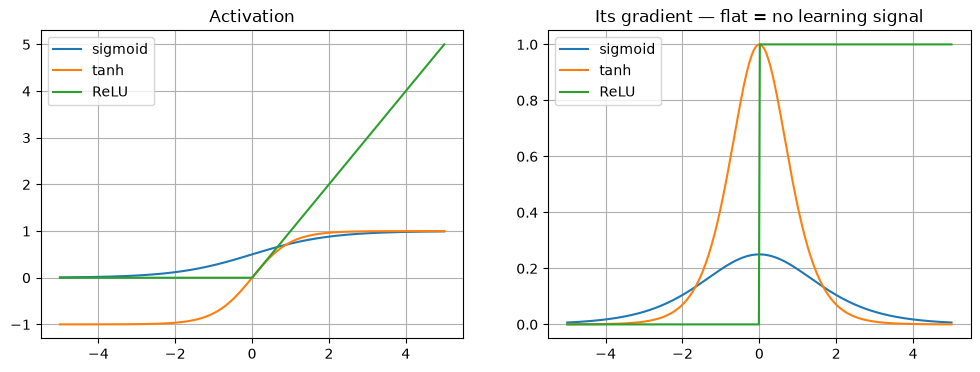

In [167]:
# The three classic activations and their gradients — the "gates" backprop multiplies by.
z = np.linspace(-5, 5, 400)
acts = {
    "sigmoid": (sigmoid(z), sigmoid(z) * (1 - sigmoid(z))),
    "tanh":    (np.tanh(z), 1 - np.tanh(z) ** 2),
    "ReLU":    (np.maximum(0, z), (z > 0).astype(float)),
}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, (a, grad) in acts.items():
    ax1.plot(z, a, label=name)
    ax2.plot(z, grad, label=name)
ax1.legend(); ax1.set_title("Activation")
ax2.legend(); ax2.set_title("Its gradient — flat = no learning signal")
plt.show()
# sigmoid's gradient peaks at 0.25 → stack 10 layers and signals shrink like 0.25**10.
# ReLU's is exactly 1 wherever active → gradients pass through undamaged (or die at exactly 0).

**Why initialization matters:** a deep net is a long chain of multiplications. If each layer slightly *shrinks* its input, 30 layers shrink it to nothing (vanishing signal); if each slightly *amplifies*, activations saturate and their gradients die. The fix — **Xavier/Glorot initialization** — scales weights by $1/\sqrt{n_{in}}$ so each layer roughly preserves signal variance. Watch: same network, three init scales, three fates.

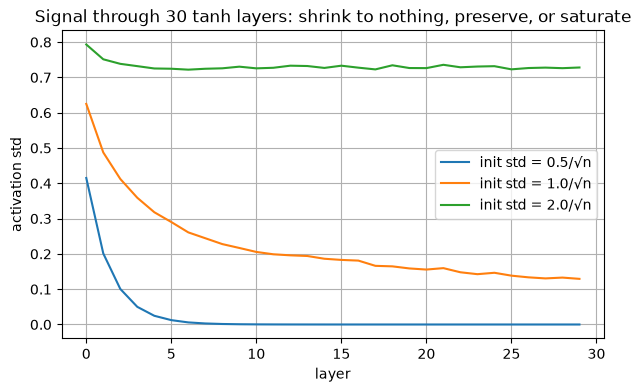

In [168]:
def signal_through_depth(scale, n_layers=30, width=100, seed=0):
    """Push a batch through n_layers of tanh layers; record activation std at each."""
    r = np.random.default_rng(seed)
    h = r.normal(size=(256, width))
    stds = []
    for _ in range(n_layers):
        W = r.normal(0, scale / np.sqrt(width), size=(width, width))
        h = np.tanh(h @ W)
        stds.append(h.std())
    return stds

for scale in [0.5, 1.0, 2.0]:
    plt.plot(signal_through_depth(scale), label=f"init std = {scale}/√n")
plt.xlabel("layer"); plt.ylabel("activation std")
plt.title("Signal through 30 tanh layers: shrink to nothing, preserve, or saturate")
plt.legend(); plt.show()

**Putting it together in PyTorch:** a 6-layer net on the moons, trained with **mini-batch SGD** — instead of the full dataset per step, sample a small random batch. Why: each step is far cheaper, and the noise it injects even helps escape flat regions of the loss. Below, a well-initialized net (PyTorch's default is Xavier-style) races the same net with weights scaled ×0.1 — the shrinking curve from the plot above, made real. The under-scaled net's loss pins at $\ln 2 \approx 0.693$: coin-flip predictions, learning nothing.

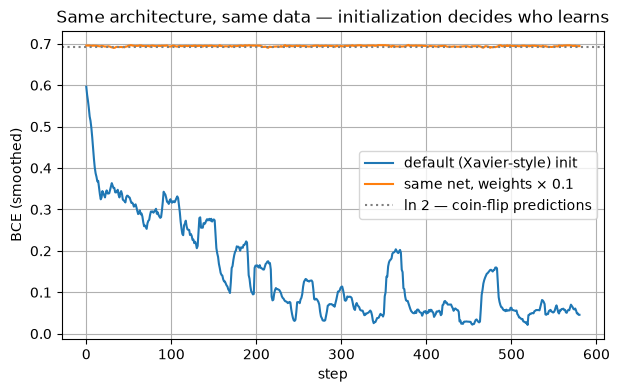

In [169]:
def make_net():
    layers = [nn.Linear(2, 32), nn.Tanh()]
    for _ in range(5):
        layers += [nn.Linear(32, 32), nn.Tanh()]
    return nn.Sequential(*layers, nn.Linear(32, 1)).to(device)

def train_net(net, steps=600, batch=32, lr=0.5):
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        idx = torch.randint(0, len(Xt), (batch,), device=device)   # Xt, yt: moons, Section 4
        loss = loss_fn(net(Xt[idx]).ravel(), yt[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

good, starved = make_net(), make_net()
with torch.no_grad():
    for p in starved.parameters():
        if p.dim() > 1:
            p.mul_(0.1)          # under-scaled weights → signal vanishes by the last layer

for name, curve in [("default (Xavier-style) init", train_net(good)),
                    ("same net, weights × 0.1", train_net(starved))]:
    plt.plot(np.convolve(curve, np.ones(20) / 20, mode="valid"), label=name)
plt.axhline(np.log(2), color="gray", ls=":", label="ln 2 — coin-flip predictions")
plt.xlabel("step"); plt.ylabel("BCE (smoothed)"); plt.legend()
plt.title("Same architecture, same data — initialization decides who learns")
plt.show()

### 🧪 Try it
1. **Dead ReLU:** rebuild the moons net with ReLU and a too-hot learning rate (`lr=5`). After training, count hidden units whose activation is 0 for *every* input — those neurons receive zero gradient forever. They're dead.
2. **He init:** rerun the depth experiment with ReLU instead of tanh. Scale $1/\sqrt{n}$ now shrinks the signal (ReLU zeroes half of it) — show that **He initialization**, $\sqrt{2}/\sqrt{n}$, restores stability.
3. **Batch-size dial:** train with batch ∈ {4, 32, 300 (full)}. Compare the noise in the loss curves and the steps needed to converge.
4. **Depth ceiling:** make the net 10 layers deep and retrain. Does it still learn? Connect what you see back to the signal-propagation plot.

In [170]:
# 🧪 scratch — Section 5


---
## 6. Overfitting & Underfitting

**Why:** the goal was never to fit the training data — it's to predict *new* data. A model can fail in two opposite ways: too rigid to capture the signal (**underfitting**, high *bias*) or flexible enough to memorize the noise (**overfitting**, high *variance*). You cannot tell the difference from training loss alone — which is why we always hold out a **validation set** the model never trains on and let it referee.

The cleanest lab for this: fit polynomials of increasing degree to noisy samples of a sine wave, and watch validation error U-turn while training error keeps falling.

📚 *Deeper dive: [Google ML Crash Course — Overfitting](https://developers.google.com/machine-learning/crash-course/overfitting); classic essay: [Understanding the Bias-Variance Tradeoff](https://scott.fortmann-roe.com/docs/BiasVariance.html)*

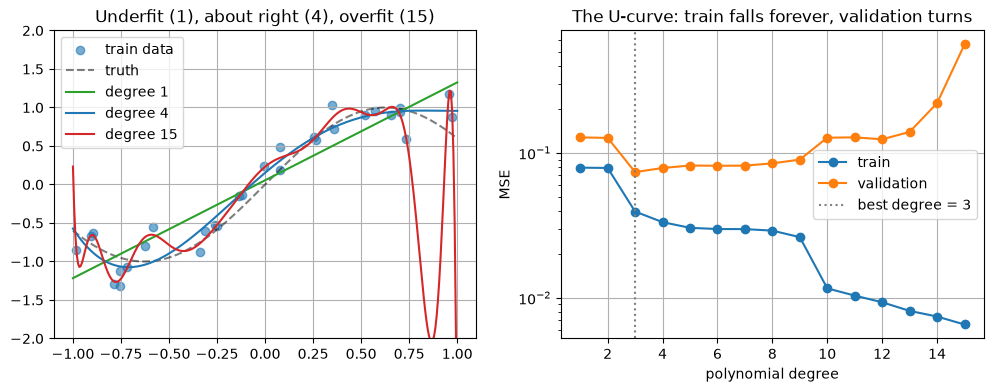

In [171]:
from numpy.polynomial import Polynomial

def true_fn(x):
    return np.sin(2.5 * x)

rng6 = np.random.default_rng(6)
x_tr = rng6.uniform(-1, 1, 30);  y_tr = true_fn(x_tr) + rng6.normal(0, 0.25, 30)
x_va = rng6.uniform(-1, 1, 100); y_va = true_fn(x_va) + rng6.normal(0, 0.25, 100)

degrees = range(1, 16)
polys = {d: Polynomial.fit(x_tr, y_tr, d) for d in degrees}
tr_err = [np.mean((polys[d](x_tr) - y_tr) ** 2) for d in degrees]
va_err = [np.mean((polys[d](x_va) - y_va) ** 2) for d in degrees]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
xg = np.linspace(-1, 1, 300)
ax1.scatter(x_tr, y_tr, alpha=0.6, label="train data")
ax1.plot(xg, true_fn(xg), "k--", alpha=0.5, label="truth")
for d, style in [(1, "C2"), (4, "C0"), (15, "C3")]:
    ax1.plot(xg, polys[d](xg), style, label=f"degree {d}")
ax1.set_ylim(-2, 2); ax1.legend(); ax1.set_title("Underfit (1), about right (4), overfit (15)")
ax2.plot(degrees, tr_err, "o-", label="train")
ax2.plot(degrees, va_err, "o-", label="validation")
best = list(degrees)[int(np.argmin(va_err))]
ax2.axvline(best, color="gray", ls=":", label=f"best degree = {best}")
ax2.set_yscale("log"); ax2.set_xlabel("polynomial degree"); ax2.set_ylabel("MSE")
ax2.legend(); ax2.set_title("The U-curve: train falls forever, validation turns")
plt.show()

**🎬 Turn the dial yourself.** The same experiment, animated: as the degree climbs from 1 to 15, the fit morphs from too-stiff to hysterical while train and validation error part ways on the right. Notice *when* the wiggles appear (after the sweet spot) and that the train curve never once complains — only the held-out data calls the bluff.

In [172]:
from IPython.display import Video

# Rendered with Manim (source: manim/overfitting_viz.py — same data, same fits).
Video("assets/overfitting-dial.mp4", width=880)

**Fixing overfitting without shrinking the model: L2 regularization.** Add a penalty $\lambda \sum w_j^2$ to the loss so large coefficients cost something. Why it works: overfitting shows up as huge, opposite-signed coefficients fighting each other to thread every noisy point; taxing their size forces smoother fits. $\lambda$ is a dial from "no tax" (overfit) to "all tax" (the model flatlines — underfit). In statistics this is **ridge regression**; in PyTorch it's the `weight_decay` argument on any optimizer.

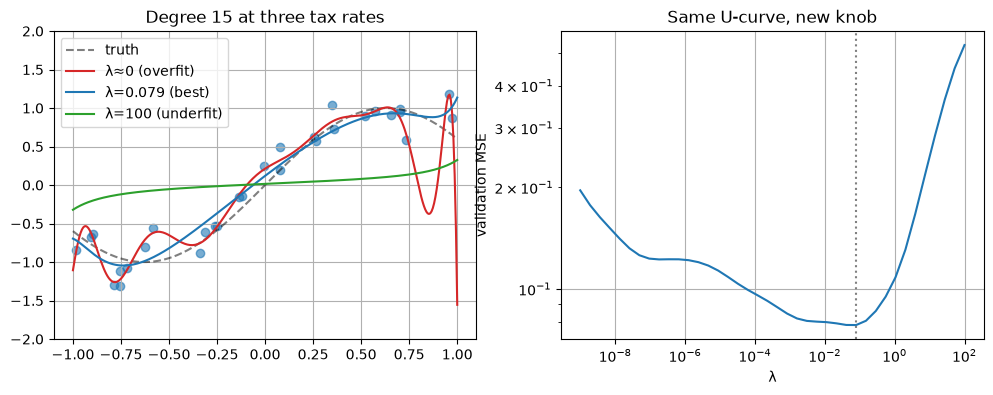

In [173]:
# Ridge on the degree-15 polynomial: closed form (XᵀX + λI)⁻¹ Xᵀy
X15_tr = np.vander(x_tr, 16, increasing=True)
X15_va = np.vander(x_va, 16, increasing=True)

def ridge(lam):
    I = np.eye(16); I[0, 0] = 0                        # don't penalize the bias term
    return np.linalg.solve(X15_tr.T @ X15_tr + lam * I, X15_tr.T @ y_tr)

lams = np.logspace(-9, 2, 40)
va_ridge = [np.mean((X15_va @ ridge(l) - y_va) ** 2) for l in lams]
best_lam = lams[int(np.argmin(va_ridge))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
Xg15 = np.vander(xg, 16, increasing=True)
ax1.scatter(x_tr, y_tr, alpha=0.6)
ax1.plot(xg, true_fn(xg), "k--", alpha=0.5, label="truth")
for lam, label, style in [(1e-9, "λ≈0 (overfit)", "C3"),
                          (best_lam, f"λ={best_lam:.3g} (best)", "C0"),
                          (100, "λ=100 (underfit)", "C2")]:
    ax1.plot(xg, Xg15 @ ridge(lam), style, label=label)
ax1.set_ylim(-2, 2); ax1.legend(); ax1.set_title("Degree 15 at three tax rates")
ax2.plot(lams, va_ridge)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.axvline(best_lam, color="gray", ls=":")
ax2.set_xlabel("λ"); ax2.set_ylabel("validation MSE"); ax2.set_title("Same U-curve, new knob")
plt.show()

### 🧪 Try it
1. **Learning curves:** fix degree 15 (λ≈0) and grow the training set from 10 to 500 points; plot train/val MSE vs N. More data is itself a regularizer.
2. **Early stopping:** fit the degree-15 model by gradient descent, tracking validation MSE every step; stop at its minimum. Compare the resulting fit to best-λ ridge — two different knobs, same medicine.
3. **`weight_decay` = ridge:** build the same model as `nn.Linear(16, 1, bias=False)` on the `X15_tr` features and train with `torch.optim.SGD(..., weight_decay=lam)`. Compare learned coefficients to `ridge(lam)`.
4. **Back to the moons:** train the Section 4 MLP with `n_hidden=256` on just 30 moon points — watch the boundary go baroque. Then tame it by adding `2 * lam * params[k]` to each weight gradient.

In [174]:
# 🧪 scratch — Section 6


---
## 7. Bootstrapping & Bagging

**Why:** everything so far produced a single answer — one slope, one accuracy — with no sense of *how much to trust it*. Would the number change if we'd collected slightly different data? Classical statistics answers with formulas that require distributional assumptions. The **bootstrap** answers by brute force: **resample your own dataset with replacement** (same size, so some points appear twice and some not at all) and refit. Each resample is a plausible alternate dataset; the spread of results across them *is* your uncertainty — no formulas, no assumptions.

Two acts in this section: first the bootstrap for **uncertainty** (confidence intervals), then the same resampling trick repurposed for **better models** (bagging).

📚 *Deeper dive: [MIT 18.05 — Bootstrap confidence intervals](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class24-prep.pdf); book-length: [An Introduction to Statistical Learning](https://www.statlearning.com/) (ch. 5.2 bootstrap, 8.2 bagging)*

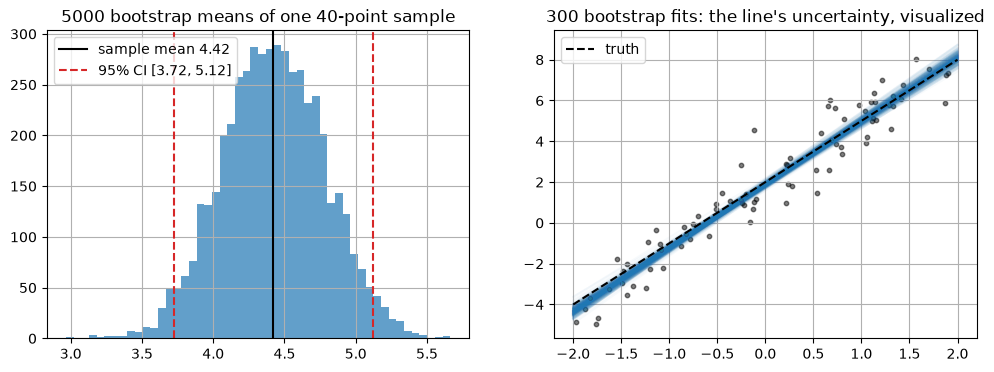

In [175]:
# Left: 95% confidence interval (CI) for a mean. Right: uncertainty of Section 1's fit line.
sample = rng.normal(5, 2, size=40)                     # one dataset, n = 40
boot_means = np.array([rng.choice(sample, size=40, replace=True).mean()
                       for _ in range(5000)])
lo, hi = np.percentile(boot_means, [2.5, 97.5])        # percentile-bootstrap CI

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(boot_means, bins=50, alpha=0.7)
ax1.axvline(sample.mean(), color="k", label=f"sample mean {sample.mean():.2f}")
ax1.axvline(lo, color="C3", ls="--", label=f"95% CI [{lo:.2f}, {hi:.2f}]")
ax1.axvline(hi, color="C3", ls="--")
ax1.legend(); ax1.set_title("5000 bootstrap means of one 40-point sample")

xs = np.array([-2, 2])
for _ in range(300):                                   # refit Section 1's line on resamples
    i = rng.integers(0, N, N)
    wi, bi = np.polyfit(x[i], y[i], 1)
    ax2.plot(xs, wi * xs + bi, color="C0", alpha=0.03)
ax2.scatter(x, y, s=10, color="k", alpha=0.5)
ax2.plot(xs, TRUE_W * xs + TRUE_B, "k--", label="truth")
ax2.legend(); ax2.set_title("300 bootstrap fits: the line's uncertainty, visualized")
plt.show()

### Bagging: the bootstrap as a training trick

So far the bootstrap *measured* uncertainty. **Bagging (bootstrap aggregating)** turns it into a weapon: train one model per bootstrap resample, then **average their predictions**. Why it works: an unstable, overfitting-prone model errs *differently* on each resample, and averaging cancels those disagreements while the shared signal survives — variance drops, bias stays put. That makes it a third fix for overfitting, alongside Section 6's regularization and early stopping — and it's the entire idea behind **random forests** (bagged decision trees, plus per-split feature sampling to decorrelate them further).

Below: each pale line is one degree-9 polynomial trained on one resample — individually erratic, collectively calm.

📚 *Deeper dive: [MLU-Explain — Random Forest](https://mlu-explain.github.io/random-forest/) (interactive visual walkthrough of bagging → random forests); new to decision trees? Start with their [Decision Trees](https://mlu-explain.github.io/decision-tree/) primer.*

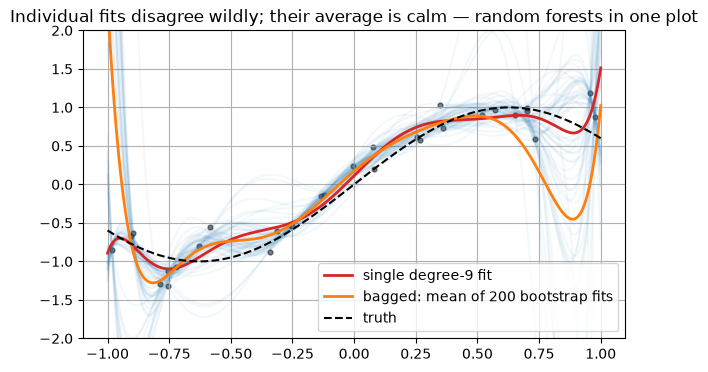

In [176]:
# Victim: a degree-9 polynomial on Section 6's 30 noisy points — wiggly and unstable.
boot_fits = []
for _ in range(200):
    i = rng.integers(0, len(x_tr), len(x_tr))
    boot_fits.append(Polynomial.fit(x_tr[i], y_tr[i], 9)(xg))
boot_fits = np.array(boot_fits)

plt.plot(xg, boot_fits[:60].T, color="C0", alpha=0.05)
plt.plot(xg, Polynomial.fit(x_tr, y_tr, 9)(xg), "C3", lw=2, label="single degree-9 fit")
plt.plot(xg, boot_fits.mean(0), "C1", lw=2, label="bagged: mean of 200 bootstrap fits")
plt.plot(xg, true_fn(xg), "k--", label="truth")
plt.scatter(x_tr, y_tr, s=12, color="k", alpha=0.5)
plt.ylim(-2, 2); plt.legend()
plt.title("Individual fits disagree wildly; their average is calm — random forests in one plot")
plt.show()

### 🧪 Try it
1. **Median CI:** bootstrap a 95% confidence interval for the *median* of `sample`. There's no tidy textbook formula for that — the bootstrap doesn't care.
2. **Coverage check:** simulate 500 fresh 40-point datasets from $\mathcal{N}(5, 2)$; for each, compute its bootstrap CI and check whether it contains the true mean 5. You should land near 95% — that's what "95% confidence" actually claims.
3. **Bag the MLP:** train 10 Section 4 MLPs on bootstrap resamples of the moons, average their probability maps, and plot with `plot_boundary` — the wobbly individual boundaries average into a smooth one.

In [177]:
# 🧪 scratch — Section 7


---
## 8. Recurrent Neural Networks (RNNs)

**Why:** every model so far took a fixed-size input. Sequences — text, audio, MIDI — have order and arbitrary length, so the network needs *memory*. An RNN reads one element at a time, folding each into a running hidden state:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

Same weights at every step — the network is a loop. Training unrolls that loop and runs Section 4's backprop along it: **backpropagation through time (BPTT)**. The catch: the error signal reaching step $t$ gets multiplied by $W_h^\top \, \text{diag}(\tanh')$ once *per step*, and repeated multiplication either shrinks it to nothing (**vanishing gradients** — the net can't learn long-range dependencies) or blows it up (**exploding** — fixed by gradient clipping). We'll see both directly.

📚 *Deeper dive: [Dive into Deep Learning — Backpropagation Through Time](https://d2l.ai/chapter_recurrent-neural-networks/bptt.html); primers: [Karpathy — The Unreasonable Effectiveness of RNNs](https://karpathy.github.io/2015/05/21/rnn-effectiveness/), [Chris Olah — Understanding LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)*

**🎬 Watch the error fade.** An unrolled RNN reads the sequence (blue, forward), then the error signal travels back through time (red) — shrinking at every hop because each one multiplies by the same $< 1$ factor. The red bars record how much learning signal each timestep receives: by the earliest steps, almost nothing. That fading bar chart *is* the vanishing-gradient problem — and the NumPy cell below measures the real thing.

In [178]:
from IPython.display import Video

# Rendered with Manim (source: manim/vanishing_gradient_viz.py).
Video("assets/vanishing-gradient.mp4", width=880)

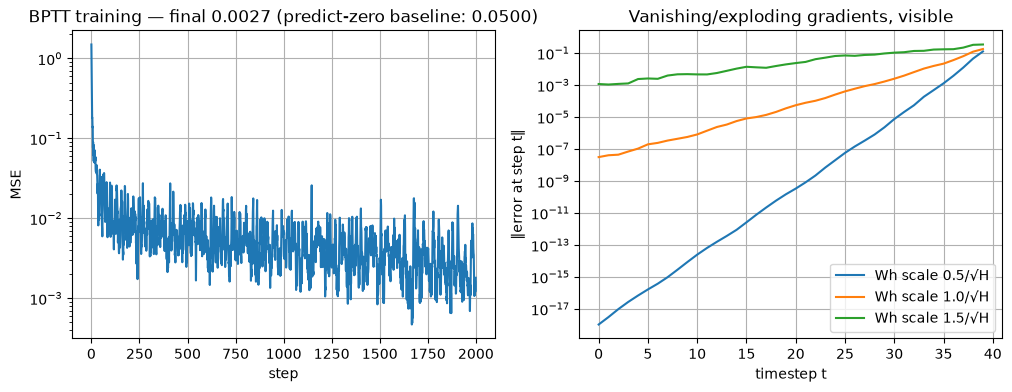

In [179]:
# Task: read a ±1 sequence, output its mean — the net must *count as it reads*.
T, B, H = 20, 64, 16

def init_rnn(scale=1.0, seed=1):
    r = np.random.default_rng(seed)
    return {"Wx": r.normal(0, 0.5, (1, H)), "Wh": r.normal(0, scale / np.sqrt(H), (H, H)),
            "bh": np.zeros(H), "Wy": r.normal(0, 0.5, (H, 1)), "by": np.zeros(1)}

def rnn_forward(p, X):                            # X: (T, B, 1)
    Hs = np.zeros((X.shape[0] + 1, X.shape[1], H))
    for t in range(X.shape[0]):
        Hs[t + 1] = np.tanh(X[t] @ p["Wx"] + Hs[t] @ p["Wh"] + p["bh"])
    return (Hs[-1] @ p["Wy"] + p["by"]).ravel(), Hs

def rnn_backward(p, X, Hs, y_hat, target):
    g = {k: np.zeros_like(v) for k, v in p.items()}
    d = (2 * (y_hat - target) / len(target))[:, None]
    g["Wy"], g["by"] = Hs[-1].T @ d, d.sum(0)
    dh, norms = d @ p["Wy"].T, []
    for t in reversed(range(X.shape[0])):         # Section 4's table, once per timestep
        norms.append(np.linalg.norm(dh))          # how much error survives back to step t
        dz = dh * (1 - Hs[t + 1] ** 2)
        g["Wx"] += X[t].T @ dz; g["Wh"] += Hs[t].T @ dz; g["bh"] += dz.sum(0)
        dh = dz @ p["Wh"].T
    return g, norms[::-1]

def make_batch(r, T, B):
    X = r.choice([-1.0, 1.0], size=(T, B, 1))
    return X, X[:, :, 0].mean(axis=0)

p8, losses8 = init_rnn(), []
for step in range(2000):
    X8, tgt = make_batch(rng, T, B)
    y_hat, Hs = rnn_forward(p8, X8)
    losses8.append(np.mean((y_hat - tgt) ** 2))
    g, _ = rnn_backward(p8, X8, Hs, y_hat, tgt)
    gn = np.sqrt(sum((v ** 2).sum() for v in g.values()))
    if gn > 1.0:                                  # gradient clipping — the exploding-gradient fix
        g = {k: v / gn for k, v in g.items()}
    for k in p8:
        p8[k] -= 0.1 * g[k]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses8); ax1.set_yscale("log"); ax1.set_xlabel("step"); ax1.set_ylabel("MSE")
ax1.set_title(f"BPTT training — final {np.mean(losses8[-50:]):.4f} "
              f"(predict-zero baseline: {1 / T:.4f})")

for scale in [0.5, 1.0, 1.5]:                     # untrained nets, longer sequence: watch δ decay
    q = init_rnn(scale=scale, seed=3)
    Xv, tv = make_batch(np.random.default_rng(7), 40, 64)
    yv, Hv = rnn_forward(q, Xv)
    _, norms = rnn_backward(q, Xv, Hv, yv, tv)
    ax2.plot(norms, label=f"Wh scale {scale}/√H")
ax2.set_yscale("log"); ax2.set_xlabel("timestep t"); ax2.set_ylabel("‖error at step t‖")
ax2.set_title("Vanishing/exploding gradients, visible"); ax2.legend()
plt.show()

**The same in PyTorch** — `nn.RNN` unrolls the loop and runs BPTT for us, on a longer sequence. We also upgrade the optimizer to **Adam (adaptive moment estimation)**: a variant of SGD that keeps per-parameter running averages of gradients to auto-tune each step size — the default workhorse for training neural nets today.

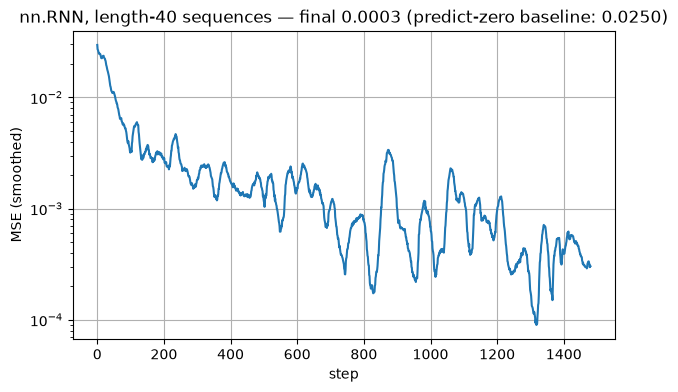

In [180]:
T_long = 40
rnn = nn.RNN(input_size=1, hidden_size=16, batch_first=True).to(device)
head = nn.Linear(16, 1).to(device)
opt = torch.optim.Adam([*rnn.parameters(), *head.parameters()], lr=0.01)

t_losses = []
for step in range(1500):
    Xb = torch.randint(0, 2, (64, T_long, 1), device=device).float() * 2 - 1
    tgt = Xb.mean(dim=(1, 2))
    out, h_T = rnn(Xb)                       # h_T: final hidden state, all the memory we get
    loss = nn.functional.mse_loss(head(h_T[-1]).ravel(), tgt)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_([*rnn.parameters(), *head.parameters()], 1.0)
    opt.step()
    t_losses.append(loss.item())

plt.plot(np.convolve(t_losses, np.ones(20) / 20, mode="valid"))
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE (smoothed)")
plt.title(f"nn.RNN, length-{T_long} sequences — final {np.mean(t_losses[-50:]):.4f} "
          f"(predict-zero baseline: {1 / T_long:.4f})")
plt.show()

### 🧪 Try it
1. **Parity:** change the target to "is the count of +1s even?" (sigmoid head + BCE). Much harder — pure memory, no partial credit. How many more steps / hidden units does it need than the mean task?
2. **Length generalization:** train at T=20, then evaluate at T=40 *without retraining*. Does counting extrapolate?
3. **LSTM rescue:** at `T_long = 100` the vanilla RNN struggles. Swap `nn.RNN` → `nn.LSTM` (note: it returns `output, (h_n, c_n)`) and compare — the gated cell state is exactly the gradient highway the 📚 Olah post diagrams.
4. **Truncated BPTT:** in `rnn_backward`, only loop over the last `k` timesteps. How small can `k` get before the mean task breaks? (This truncation is how production RNNs kept memory affordable.)

In [181]:
# 🧪 scratch — Section 8
